# Relacion 5 Nanoelectrónica

In [138]:
### LIBRERIAS ########################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [150]:
### Constantes universales #######################

hbar = 6.582*10**(-16)     #eV*s

h = 4.1357*10**(-15)        #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 

m = 9.1*10**(-31)           #kg

### Ejercicio 1: Realizar ejercicio 5.1 de Marc Baldo.

In [162]:
### Parámetros para ejercicio 1 ##########################

T = 1.0                 # K
KT= kbtz*T
Gamma = 0.1             # eV  
Gamma_S = Gamma / 2     # eV
Gamma_D = Gamma / 2     # eV

E_F = -5.0       # eV
E_LUMO = -4.7       # eV

#Capacidades, lo pongo directamente en F y no en aF
C_S = 10e-18        # F
C_D = 10e-18        # F
C_G = 1e-18         # F
C_ES = C_S + C_D + C_G
alpha_G = C_G / C_ES
alpha_D = C_D / C_ES



In [ ]:
### FUNCIONES EJERCICIO 1 ##########
def fermi(energia, e_fermi):
    """
    Args:
        energia (Float or array): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    
    x = (energia - e_fermi)/(KT + 1e-15)
    x_clipped = np.clip(x, -700.0, 700.0)
    return 1.0/(1.0 + np.exp(x_clipped))


#Mi U lo itento poner como función
def molecular_U_eV(VGS, VDS):
    return -(alpha_G * VGS + alpha_D * VDS)


#Densidad de estados lorenziana

def lorentzian_DOS(E, E0, Gamma):
    return (Gamma / (2*np.pi)) / ((E - E0)**2 + (Gamma/2)**2)


#Función corriente SIN AUTOCONSISTENCIA, uso la fórmula del tema pasado del scattering.

def current(VGS, VDS):
    U = molecular_U_eV(VGS, VDS)
    E_level = E_LUMO + U

    mu_S = E_F
    mu_D = E_F - VDS

    E_min = min(mu_S, mu_D, E_level) - 2.0
    E_max = max(mu_S, mu_D, E_level) + 2.0
    E = np.linspace(E_min, E_max, 12000)

    T_E = (Gamma_S * Gamma_D) / ((E - E_level)**2 + (Gamma/2)**2) #Tenemos una lorentziana y no una delta, tenemos por tanto una transmisión -> Uso Landauer. (he buscado la expresión de T)
    fS = fermi(E, mu_S)
    fD = fermi(E, mu_D)

    I = (2 * q / h) * np.trapezoid(T_E * (fS - fD), E)

    return I


#Conductancia numérica. Si uso la función gradiente se ralla.
def conductance_numeric(VGS, VDS, dV=1e-4):
    I_plus = current(VGS, VDS + dV)
    I_minus = current(VGS, VDS - dV)
    return (I_plus - I_minus) / (2 * dV)


#Densidad delta:
def fermi_delta(E, mu):
    if E < mu:
        return 1.0
    else:
        return 0.0
    
#Corriente con delta:
def current_delta(VGS, VDS):
    U = molecular_U_eV(VGS, VDS)
    E_level = E_LUMO + U

    mu_S = E_F
    mu_D = E_F - VDS

    Gamma_eff = (Gamma_S * Gamma_D) / (Gamma_S + Gamma_D)

    fS = fermi_delta(E_level, mu_S)
    fD = fermi_delta(E_level, mu_D)

    I = (2 * q / h) * Gamma_eff * (fS - fD)

    return I

#Conductancia con delta:
def conductance_numeric_delta(VGS, VDS, dV=1e-4):
    I_plus = current_delta(VGS, VDS + dV)
    I_minus = current_delta(VGS, VDS - dV)
    return (I_plus - I_minus) / (2 * dV)



In [ ]:
### CÓDIGO EJERCICIO 1 ##################

#Creo un mallado para que me de los valores en dicha malla, así creo un plot en 2D. El paso será de 0,01

VDS_map = np.arange(-0.2, 0.2 + 1e-12, 0.01)   #zona fina única
VGS_map = np.linspace(5.0, 8.0, 301)

VGS_c = 5.9 #fijo el valor que me dicen de la gate
VDS_iv = np.linspace(-0.2, 0.2, 201)    #Mismo mallado para las curvas de I-V



## APARTADO A #########################

#Voy a crear una matriz que me defina la conductancia en cada cuadradito
Gmap = np.zeros((len(VGS_map), len(VDS_map))) 

for i, VGS in enumerate(VGS_map):
    for j, VDS in enumerate(VDS_map):
        Gmap[i, j] = conductance_numeric(VGS, VDS)

Gmap_uS = 1e6 * Gmap


## PARTADO B ########################

#Creo dos líneas, que vaya una con el source y la otra con el drenador. E_nivel = mu_s; E_lumo + U = Ef -> E_lumo - alfa_g*Vgs - alfa_d*Vds = Ef. Lo mismo para mu_d=Ef-Vds

VGS_line_source = (E_LUMO - E_F - alpha_D * VDS_map) / alpha_G      
VGS_line_drain  = (E_LUMO - E_F + (1 - alpha_D) * VDS_map) / alpha_G


## APARTADO C ##################

I = np.array([current(VGS_c, v) for v in VDS_iv])
I_uA = 1e6 * I





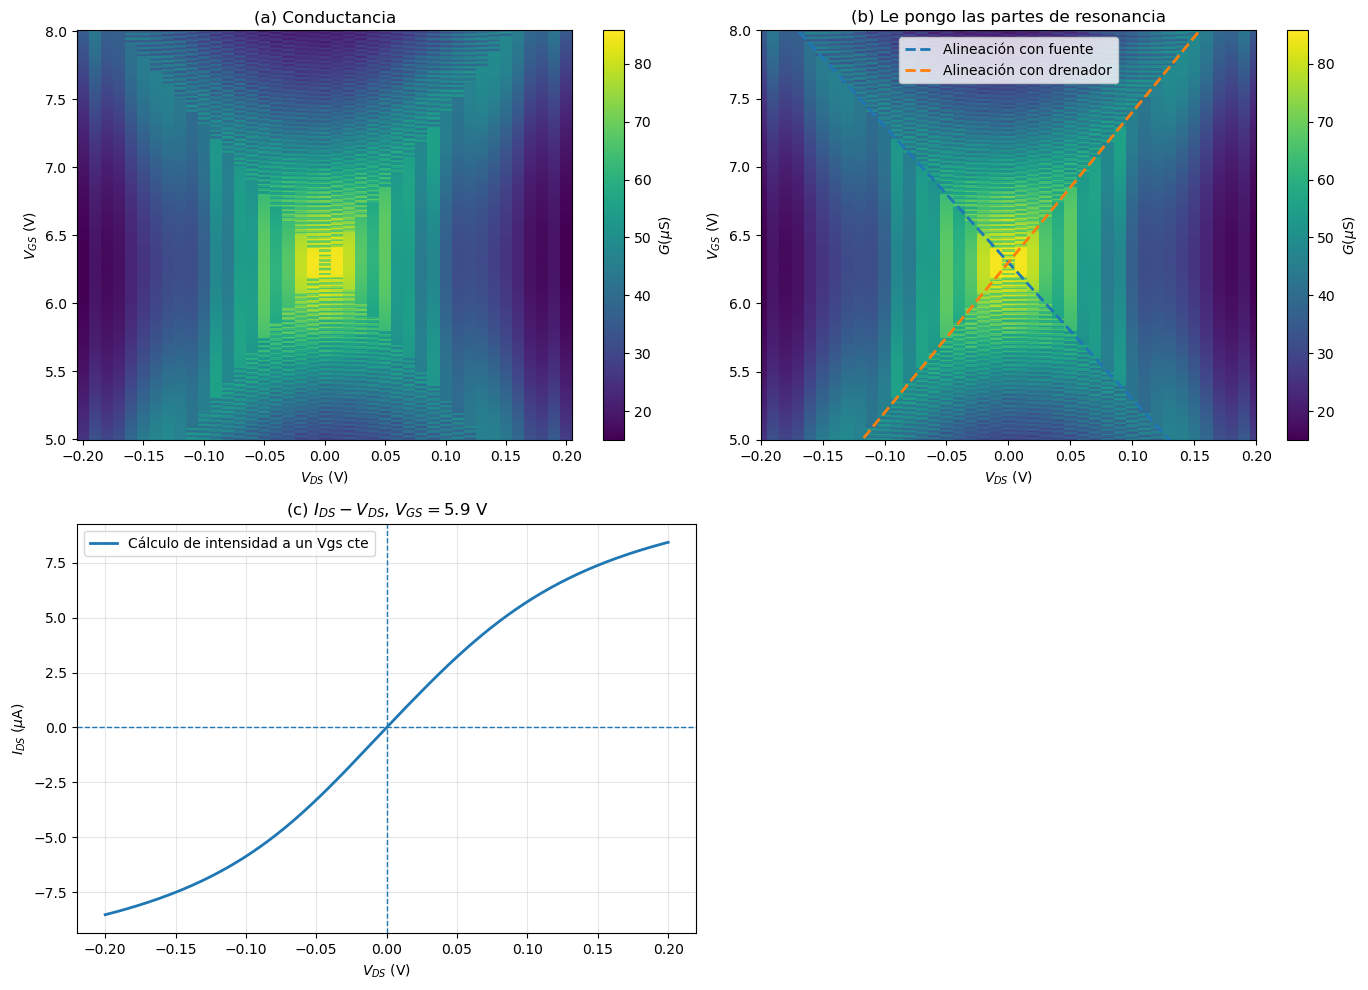

In [ ]:
### PLOT EJERCICIO 1 ###################

fig = plt.figure(figsize=(14, 10))

#APARTADO A
ax1 = plt.subplot(2, 2, 1)
im = ax1.pcolormesh(VDS_map, VGS_map, Gmap_uS, shading='auto')
plt.colorbar(im, ax=ax1, label=r'$G (\mu$S)')
ax1.set_xlabel(r'$V_{DS}$ (V)')
ax1.set_ylabel(r'$V_{GS}$ (V)')
ax1.set_title('(a) Conductancia')

#APARTADO B
ax2 = plt.subplot(2, 2, 2)
im2 = ax2.pcolormesh(VDS_map, VGS_map, Gmap_uS, shading='auto')
plt.colorbar(im2, ax=ax2, label=r'$G (\mu$S)')
ax2.plot(VDS_map, VGS_line_source, '--', linewidth=2, label='Alineación con fuente')    #Que me dibuje la linea pinteada donde coinciden los valores de VDS_map con la fuente y el drenador. Vamos, E_nivel = mu_s
ax2.plot(VDS_map, VGS_line_drain, '--', linewidth=2, label='Alineación con drenador')
ax2.set_xlim(VDS_map.min(), VDS_map.max())  
ax2.set_ylim(VGS_map.min(), VGS_map.max())
ax2.set_xlabel(r'$V_{DS}$ (V)')
ax2.set_ylabel(r'$V_{GS}$ (V)')
ax2.set_title('(b) Le pongo las partes de resonancia')
ax2.legend()

#APARTADO C 
ax3 = plt.subplot(2, 2, 3)
ax3.plot(VDS_iv, I_uA, linewidth=2, label='Cálculo de intensidad a un Vgs cte')
ax3.axhline(0, linestyle='--', linewidth=1)
ax3.axvline(0, linestyle='--', linewidth=1)
ax3.set_xlabel(r'$V_{DS}$ (V)')
ax3.set_ylabel(r'$I_{DS}$ ($\mu$A)')
ax3.set_title(rf'(c) $I_{{DS}}-V_{{DS}}$, $V_{{GS}}={VGS_c}$ V')
ax3.legend()
ax3.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()


In [169]:
### CÓDIGO EJERCICIO 1 CON DELTA ###################
VDS_map = np.arange(-0.2, 0.2 + 1e-12, 0.01)
VGS_map = np.linspace(5.0, 8.0, 301)

VGS_c = 5.9
VDS_iv = np.linspace(-0.2, 0.2, 201)


## APARTADO A #########################

Gmap_delta = np.zeros((len(VGS_map), len(VDS_map)))

for i, VGS in enumerate(VGS_map):
    for j, VDS in enumerate(VDS_map):
        Gmap_delta[i, j] = conductance_numeric_delta(VGS, VDS)

Gmap_delta_uS = 1e6 * Gmap_delta


## APARTADO B ########################

VGS_line_source = (E_LUMO - E_F - alpha_D * VDS_map) / alpha_G
VGS_line_drain  = (E_LUMO - E_F + (1 - alpha_D) * VDS_map) / alpha_G


## APARTADO C ##################

I_delta = np.array([current_delta(VGS_c, v) for v in VDS_iv])
I_delta_uA = 1e6 * I_delta

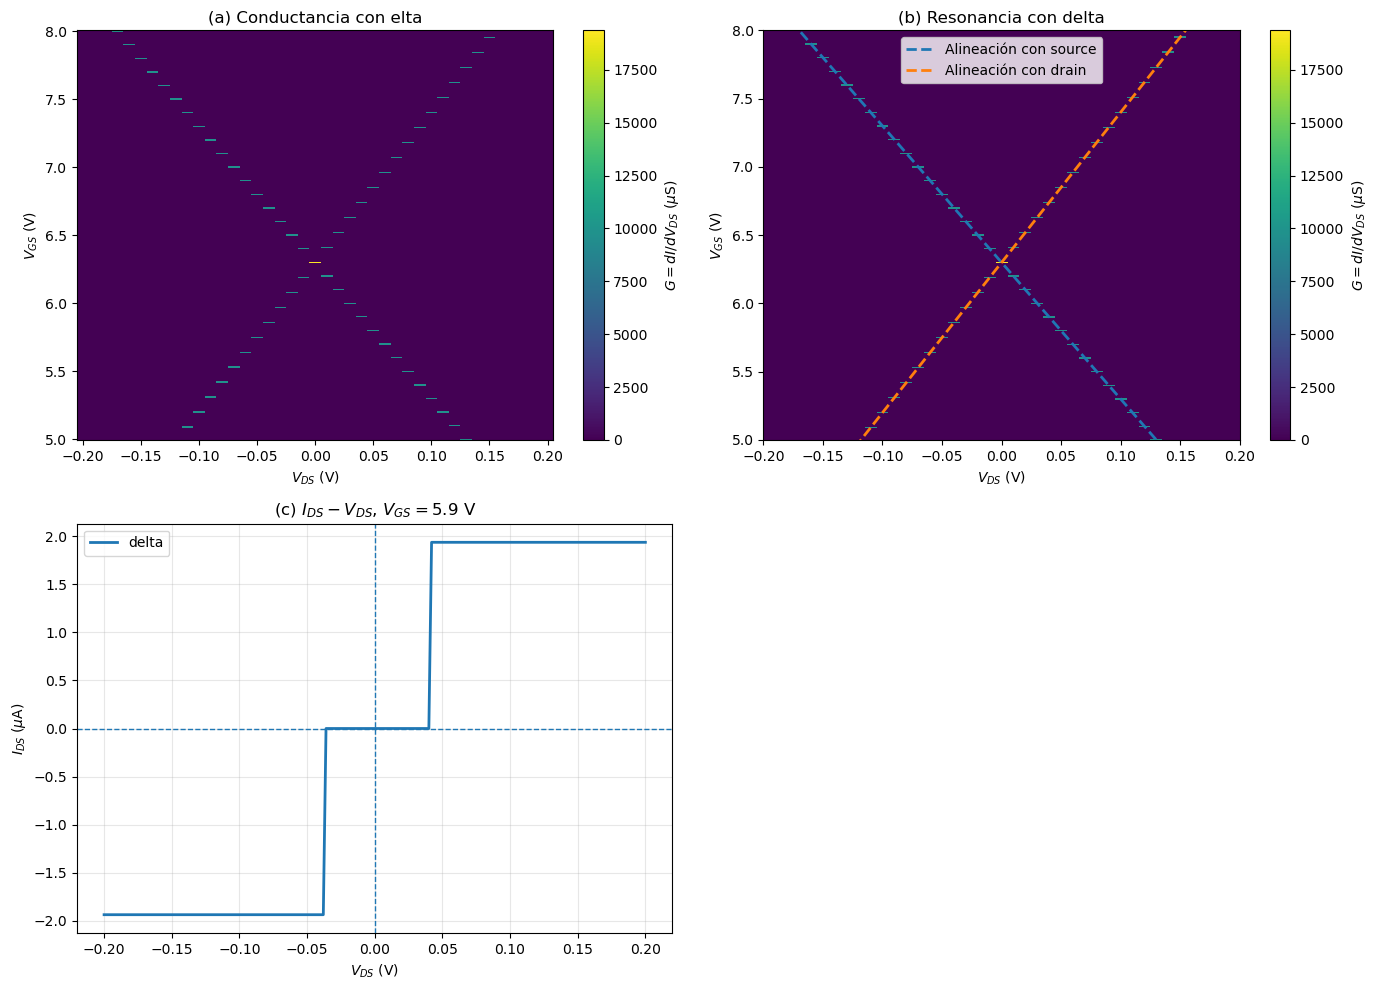

In [184]:
### PLOT EJERCICIO 1 DELTA ###################

fig = plt.figure(figsize=(14, 10))

# (a) Mapa de conductancia
ax1 = plt.subplot(2, 2, 1)
im = ax1.pcolormesh(VDS_map, VGS_map, Gmap_delta_uS, shading='auto')
plt.colorbar(im, ax=ax1, label=r'$G = dI/dV_{DS}$ ($\mu$S)')
ax1.set_xlabel(r'$V_{DS}$ (V)')
ax1.set_ylabel(r'$V_{GS}$ (V)')
ax1.set_title('(a) Conductancia con elta')


# (b) Forma en X
ax2 = plt.subplot(2, 2, 2)
im2 = ax2.pcolormesh(VDS_map, VGS_map, Gmap_delta_uS, shading='auto')
plt.colorbar(im2, ax=ax2, label=r'$G = dI/dV_{DS}$ ($\mu$S)')
ax2.plot(VDS_map, VGS_line_source, '--', linewidth=2, label='Alineación con source')
ax2.plot(VDS_map, VGS_line_drain, '--', linewidth=2, label='Alineación con drain')
ax2.set_xlim(VDS_map.min(), VDS_map.max())
ax2.set_ylim(VGS_map.min(), VGS_map.max())
ax2.set_xlabel(r'$V_{DS}$ (V)')
ax2.set_ylabel(r'$V_{GS}$ (V)')
ax2.set_title('(b) Resonancia con delta')
ax2.legend()


# (c) IDS-VDS con delta
ax3 = plt.subplot(2, 2, 3)
ax3.plot(VDS_iv, I_delta_uA, linewidth=2, label='delta')
ax3.axhline(0, linestyle='--', linewidth=1)
ax3.axvline(0, linestyle='--', linewidth=1)
ax3.set_xlabel(r'$V_{DS}$ (V)')
ax3.set_ylabel(r'$I_{DS}$ ($\mu$A)')
ax3.set_title(rf'(c) $I_{{DS}}-V_{{DS}}$, $V_{{GS}}={VGS_c}$ V')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [187]:
### APARTADO D EJERCICIO 1 #######################

VGS_gap = 6.0   #Aquí desaparece

C_S=10
C_D=10  #aF

DE = E_LUMO-E_F #eV

alpha_G_correcto = DE/VGS_gap

CG_correcto = alpha_G_correcto*(C_S + C_D)/(1-alpha_G_correcto)
print("CG correcto en aF:", CG_correcto)

CG correcto en aF: 1.0526315789473677


**Explicación apartado b**.

Tenemos el c60 que como es una molécula tiene niveles discretos de energía. También estamos a una temperatura baja, por lo que podemos aproximar la anchura de los niveles a una delta y que las funciones de fermi son escalones. Eso significa que solo tenemos una ventana VDS para que pueda haber circulación. Tendremos nuestro pico cuando uno de los niveles de energía coincida con la ventana que deja $mu_s$ y $mu_D$. Como ahí es cuando se reanuda la conducción y la conductancia es la derivada, tenemos un pico en G. 

Como además nos estamos moviendo en una malla muy pequeña de VDS(del orden de mV) frente a lo que acomoda el nivel de la molécula, VGS (del orden de dV), entonces solo tendremos unos pequeños valores para los que coinciden ambas magnitudes, haciendo así que tenga forma de diagonal. La otra diagonal viene a que da igual si yo subo el nivel y subo aúm más $mu_S$ o si yo bajo el nivel pero bajo aún más $mu_D$

### Ejercicio 2:

**Considere el hilo (Quantum Wire) de la siguiente figura: Este hilo presenta solo dos modos energéticos localizados en $E_{c1}=-4.7$ eV y en $E_{c2}=-4.6$ eV. Desarrolle una expresión analítica de la curva $I_{DS}-V_{DS}$ en función de $V_{GS} a T=0K. Represente la solución para 0<$V_{DS}$<0.5 en los casos $V_{GS}$ = 0.3V, 0.35V, 0.4V, 0.45V, 0.5V. Suponer $C_S=C_D= 0$, $C_G = 50$aF/nm y L=100nm**

Vamos con la expresión analítica. Como estamos a T=0 la función de fermi es un escalón y tenemos transmisión 1, por tanto
$$
I_{DS} = \frac{2q}{h}\int_{-\infty}^{\infty}M(E)*(f(E,\mu_s)-f(E,\mu_D))dE = \frac{2q}{h}\int_{\mu_D}^{\mu_S}M(E)dE
$$

Ahora bien, hay que ver donde viven los modos. Tenemos dos canales a niveles distintos y consideramos que Cs=Cd=Cq=0, por tanto solo nos modifica el nivel VGS. Tamibén podemos decir que $\mu_D = \mu_S - V_{DS}$ 
$$
I_{DS} = \frac{2q}{h}\int_{\mu_S - V_{DS}}^{\mu_S}(u(E-E_{c_1}-qV_{GS})-u(E-E_{c_2}-qV_{GS}))dE
$$


Podemos reescribir esto en función de los voltajes umbrales. Para nuestros canales 1 y 2 serán $V_{T_1}$ y $V_{T_2}$ que son la diferencia entre los niveles iniciales de los canales y el de fermi

$$
I_{DS} = \frac{2q}{h}*[min(V_{DS}, V_{GT}-V_{T_1}) + min(V_{DS}, V_{GS}-V_{T_2})]
$$

Para nuestro caso, obtenemos esta relación:
$$
\min(V_{DS}, V_{GS} - V_{Tn}) =
\begin{cases}
0, & V_{GS} < V_{Tn} \\[6pt]
V_{DS}, & V_{GS} > V_{Tn} \;\text{y}\; V_{DS} < V_{GS} - V_{Tn} \\[6pt]
V_{GS} - V_{Tn}, & V_{GS} > V_{Tn} \;\text{y}\; V_{DS} > V_{GS} - V_{Tn}
\end{cases}
$$

Ahora hacemos los tramos propuestos por el ejercicio: (defino $G_0 = \frac{2q}{h}$)

**Para $V_{GS}=0.3V** No está activo ninguno

$V_{GS} - V_{T1} = 0, \qquad V_{GS} - V_{T2} < 0$ --> $I_{DS} = 0$

**Para $V_{GS}=0.35V** Se activa el primer canal

$V_{GS} - V_{T1} = 0.05, \qquad V_{GS} - V_{T2} < 0$ --> $I_{DS} = G_0 \min(V_{DS}, 0.05)$

**Para $V_{GS}=0.4V** Sigue solo el primer canal

$V_{GS} - V_{T1} = 0.10, \qquad V_{GS} - V_{T2} = 0$ --> $I_{DS} = G_0 \min(V_{DS}, 0.10)$

**Para $V_{GS}=0.45V** Se activa el segundo canal

$V_{GS} - V_{T1} = 0.15, \qquad V_{GS} - V_{T2} = 0.05$ --> $I_{DS} = G_0 \min(V_{DS}, 0.15) + G_0 \min(V_{DS}, 0.05)$

Podemos de nuevo hacer un desglose
$$
I_{DS} =
\begin{cases}
2G_0 V_{DS}, & 0 < V_{DS} < 0.05 \\[6pt]
G_0 V_{DS} + 0.05 G_0, & 0.05 < V_{DS} < 0.15 \\[6pt]
0.20 G_0, & V_{DS} > 0.15
\end{cases}
$$


**Para $V_{GS}=0.5V** Siguen los dos canales

$V_{GS} - V_{T1} = 0.20, \qquad V_{GS} - V_{T2} = 0.10$ --> $I_{DS} = G_0 \min(V_{DS}, 0.20) + G_0 \min(V_{DS}, 0.10)$

$$
I_{DS} =
\begin{cases}
2G_0 V_{DS}, & 0 < V_{DS} < 0.10 \\[6pt]
G_0 V_{DS} + 0.10 G_0, & 0.10 < V_{DS} < 0.20 \\[6pt]
0.30 G_0, & V_{DS} > 0.20
\end{cases}
$$

In [216]:
### Definición de parámetros para el ejercicio 2 ############################

T = 0               #K
KT = 0.026*T/300    #eV
L = 100             #nm
Ef0 = -5.0          #eV

mu_s0 = Ef0     
mu_d0 = Ef0

G0 = 2 * q / h   # A/V #ya trabajo en unidades naturales asi que no me hace falta el q^2 sino solo q

Cs = 0.0
Cd = 0.0
Cg = 50.0         #aF/nm
CES = (Cs+Cd+Cg)


Vmax = 10.0         #V
numpasos = 301      #Cantidad de pasos desde -Vmax hasta Vmax
precision = 10**(-6)    #Precisión a la hora de converger U


#Creo el vector de voltajes y las energías

VGS_array = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 70)
Ec_modes_0 = np.array([-4.7, -4.6])   #eV
numpasosE=4000  #Si pones menos de 3000 las curvas salen woobly, salen no rectas.



In [217]:
### FUNCIONES ############

def fermi(energia, e_fermi):
    """
    Args:
        energia (Float or array): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    x = (energia - e_fermi)/(KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0/(1.0 + np.exp(x_clipped))

def densidad_g(energia, Ec):
    x = L*10**(-9)/(np.pi*hbar)*np.sqrt(2*m)
    
    y = np.heaviside(energia-Ec, 0)/((energia-Ec + 1e-10))**0.5 #Le pongo eso para que no explote
    return x*y

def funcion_N(energia, Ec_array, U, mus, mud):
    aux=0.0
    for Ec_aux in Ec_array:
        
        if energia - U > Ec_aux:
            aux+= densidad_g(energia-U, Ec_aux)*(fermi(energia, mus)+fermi(energia,mud))/2
    return aux

def funcion_I(energia, Ec_array, U, mus, mud):
    aux=0.0
    for Ec_aux in Ec_array:
        if energia - U > Ec_aux:
            aux+=2*q/h*(fermi(energia, mus)-fermi(energia,mud))
    return aux

    

In [218]:
### CÓDIGO PARA EL EJERCICIO 2 ######################
T=0
KT = 0.026*T/300    #eV

IDS_total =[]

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
           
        mu_s=Ef0
        mu_d=Ef0-VDS
        
        Ec_eff = Ec_modes_0 - VGS*Cg/CES
        
        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2      #Pongo 0.2 porque el profe puso 0.2 para ver que todo se cumplía. Y efectivamente y de sobra.
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        fs = fermi(E, mu_s)
        fd = fermi(E, mu_d)
        
        #Calculo el número de modos disponibles.
        M=[]
        for e in E:
            i=0
            for Ec in Ec_eff:
                if e>=Ec:
                    i+=1
            M.append(i)
    
        IDS = G0*np.trapezoid(M*(fs-fd), E)
        IDS_VDS.append(IDS)
    
    IDS_total.append(IDS_VDS)

IDS_total = np.array(IDS_total, dtype=float)


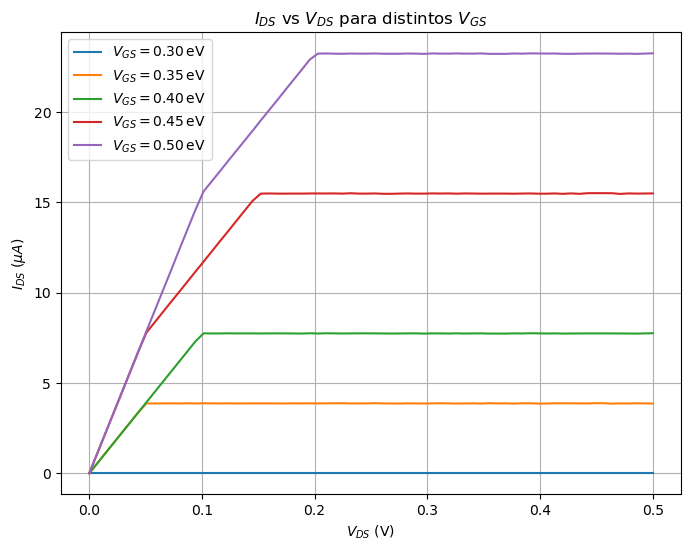

In [219]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$eV")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

In [220]:
### MISMO CÓDIGO PARA T= 298K ###############

T=298
KT = 0.026*T/300    #eV


IDS_total =[]

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
           
        mu_s=Ef0
        mu_d=Ef0-VDS
        
        Ec_eff = Ec_modes_0 - VGS*Cg/CES
        
        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2      #Pongo 0.2 porque el profe puso 0.2 para ver que todo se cumplía. Y efectivamente y de sobra.
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        fs = fermi(E, mu_s)
        fd = fermi(E, mu_d)
        
        #Calculo el número de modos disponibles.
        M=[]
        for e in E:
            i=0
            for Ec in Ec_eff:
                if e>=Ec:
                    i+=1
            M.append(i)
    
        IDS = G0*np.trapezoid(M*(fs-fd), E)
        IDS_VDS.append(IDS)
    
    IDS_total.append(IDS_VDS)

IDS_total = np.array(IDS_total, dtype=float)


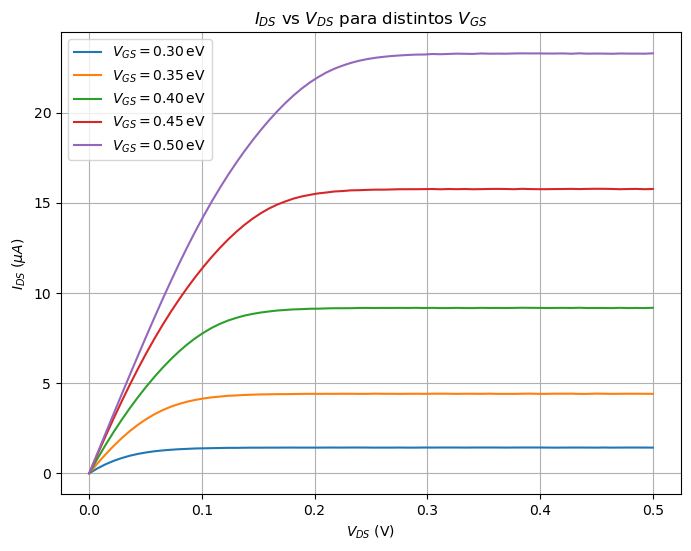

In [221]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$eV")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

In [212]:
### FUNCIONES VERSION 1###############################################

def fermi(energia, e_fermi):
    x = (energia - e_fermi) / (KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0 / (1.0 + np.exp(x_clipped))


def densidad_g(energia, Ec):
    """
    DOS 1D de un canal.
    energia y Ec en eV
    devuelve la DOS en SI
    """
    if energia > Ec:
        pref = L*1e-9/(np.pi*hbar) * np.sqrt(2*m/q)
        return pref / np.sqrt(energia - Ec + 1e-10)
    else:
        return 0.0


def funcion_N(energia, Ec_array, U, mus, mud):
    """
    Integrando de N:
    g(E-U) * (fs + fd)/2
    """
    aux = 0.0
    
    for Ec_aux in Ec_array:
        aux += densidad_g(energia + U, Ec_aux) * 0.5 * (
            fermi(energia, mus) + fermi(energia, mud)
        )
    
    return aux


def funcion_I(energia, Ec_array, U, mus, mud):
    """
    Integrando de I:
    (2q/h) * M(E-U) * (fs - fd)
    """
    M = 0.0
    
    for Ec_aux in Ec_array:
        if energia + U > Ec_aux:
            M += 1.0
    
    return (2*q/h) * M * (fermi(energia, mus) - fermi(energia, mud))

In [129]:
### CÓDIGO PRINCIPAL CON AUTOCONSISTENCIA ###################

T = 298
KT = 0.026*T/300    # eV
numpasosE = 2000

tolerancia = 1e-5
alfa = 0.1
maxiteracion = 70

#Capacidad total
CES = Cg + Cs + Cd
#Calculo numero de electrones en equilibrio

mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0
Emin0 = min(np.min(Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max(np.max(Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin, Emax, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapezoid(integrando_N, E)

#Ahora hago el bucle total igual que antes, pero le metro otro para la autoconsistencia.
IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        Ec_eff = Ec_modes_0 #Ya tengo en cuenta el efecto de U, lo uso ahora solo por notacion

        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        
        #Semilla sin tener en cuenta el charging
        U_old = VGS*Cg/CES + VDS*Cd/CES

        error = 1.0
        numiteracion = 0

        while error > tolerancia and numiteracion < maxiteracion:
            
        
            # Cálculo de N con el U actual
            integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
            num_e = np.trapezoid(integrando_N, E)
            
            
            #Calculo el nuevo valor de U teórico
            U_aux = VGS*Cg/CES + VDS*Cd/CES + q/CES * (num_e - num_e0)
            #Le meto el alfa igual que en la relación 3 y calculo el nuevo valor de U
            U_new = U_old + alfa*(U_aux - U_old)
            #error para ver si ha convergido suficiente
            error = np.abs(U_new - U_old)
            U_old = U_new
            numiteracion += 1

        # Corriente con U convergido
        integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        i_aux = np.trapezoid(integrando_I, E)
        #Salimos del bucle y meto la intensidad de Vds
        IDS_VDS.append(i_aux)
    #Salimos del bucle y meto la curva de intensidad para un VGS
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    
#Lo pongo como np para que tarde menos en plotear
IDS_total = np.array(IDS_total, dtype=float)

0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


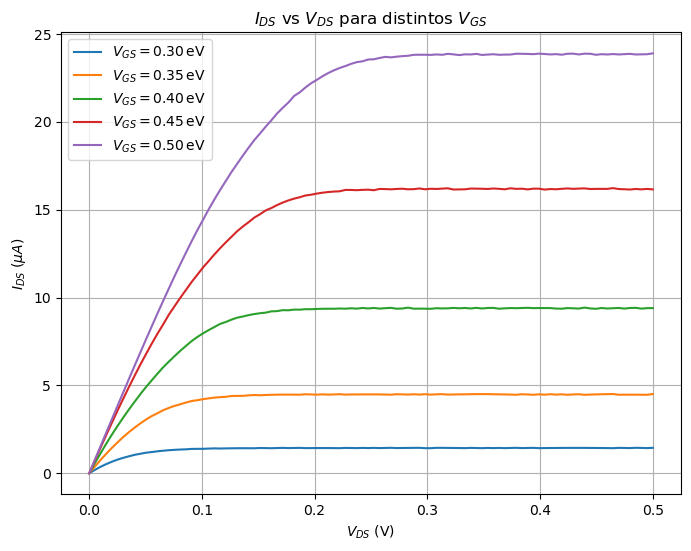

In [130]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$eV")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

In [213]:
### FUNCIONES  OPTIMIZADO CHATGPT VERSION 2 ###################

#Le he pedido a chatgpt que me optimice el código poniéndome las funciones que les pasara las variables como lista porque no sabía hacerlo.
#El código es exactamente el mismo, pero no tarda tanto por eso, porque las definiciones son las mismas pero los hace todo el vector a la vez.



def fermi(energia, e_fermi):
    x = (energia - e_fermi)/(KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0/(1.0 + np.exp(x_clipped))


def densidad_g(energia, Ec):
    pref = L*1e-9/(np.pi*hbar) * np.sqrt(2*m/q)
    delta = energia - Ec
    return pref * np.heaviside(delta, 0.0) / np.sqrt(np.maximum(delta, 1e-15))


def funcion_N(energia, Ec_array, U, mu_s, mu_d):
    g_total = np.zeros_like(energia, dtype=float)

    for Ec_aux in Ec_array:
        g_total += densidad_g(energia + U, Ec_aux)

    return g_total * 0.5 * (fermi(energia, mu_s) + fermi(energia, mu_d))


def funcion_I(energia, Ec_array, U, mu_s, mu_d):
    M = np.zeros_like(energia, dtype=float)

    for Ec_aux in Ec_array:
        M += (energia + U > Ec_aux)

    return (2*q/h) * M * (fermi(energia, mu_s) - fermi(energia, mu_d))

In [214]:
### CÓDIGO OPTIMIZADO CHATGPT PRINCIPAL CON AUTOCONSISTENCIA ###################

T = 298
KT = 0.026*T/300    # eV
numpasosE = 4000

tolerancia = 1e-5
alfa = 0.1
maxiteracion = 100

CES = Cg + Cs + Cd


mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0

Emin0 = min(np.min(Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max(np.max(Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = funcion_N(E, Ec_modes_0, U0, mu_s0, mu_d0)
num_e0 = np.trapezoid(integrando_N, E)

IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS

        Ec_eff = Ec_modes_0 

        U_old = VGS*Cg/CES + VDS*Cd/CES

        Emin = min(np.min(Ec_eff - U_old), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff - U_old), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)

        error = 1.0
        numiteracion = 0

        while error > tolerancia and numiteracion < maxiteracion:
            
            integrando_N = funcion_N(E, Ec_eff, U_old, mu_s, mu_d)
            num_e = np.trapezoid(integrando_N, E)

            U_aux = VGS*Cg/CES + VDS*Cd/CES + q/CES*(num_e - num_e0)

            U_new = U_old + alfa*(U_aux - U_old)

            error = np.abs(U_new - U_old)
            U_old = U_new
            numiteracion += 1

        integrando_I = funcion_I(E, Ec_eff, U_old, mu_s, mu_d)
        i_aux = np.trapezoid(integrando_I, E)

        IDS_VDS.append(i_aux)

    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")

IDS_total = np.array(IDS_total, dtype=float)

0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


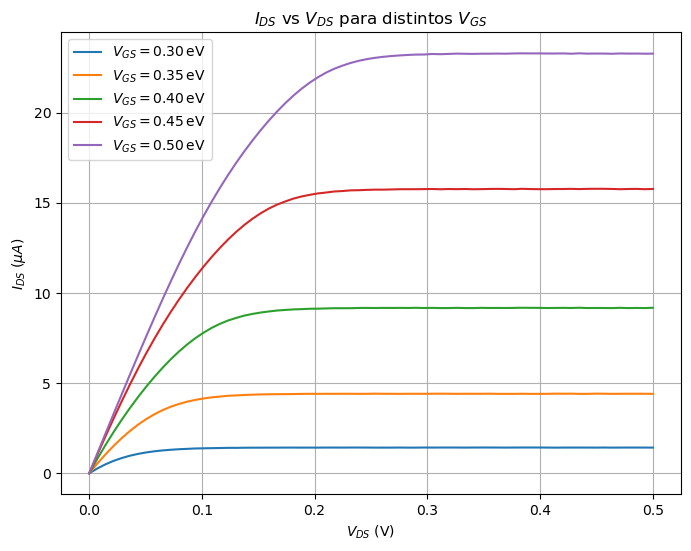

In [215]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$eV")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

### Ejercicio 3 Deducir las siguientes expresiones
$$
I_{DS}
$$

Partimos de la ecuación de la intensidad, que como estamos en 2D, $\tau = L/V_x$ siendo $V_x$ la componente que conecta la fuente y drenador
$$
I = \frac{q (N_S-N_D)}{\tau} = \frac{qv_x(N_S-N_D)}{L}
$$

Por otra parte, para obtener ese N necesitamos la densidad de estados. Dicho diferencial luego integraremos para obtener N. Si escribimos N en función de k y luego derivamos obtenemos
$$
g(k)dk = \frac{2LW d^2k}{(2\pi)^2}
$$
Si ahora lo expresamos en "polares" con k el módulo y $\theta$ el ángulo (siendo la dirección y con ángulo 0 y creciente en sentido horario, o viceversa) y le adjuntamos la velocidad $v_x$:
$$
g(k)\cdot v_xdkd\theta = \frac{2LWk }{(2\pi)^2}\cdot \frac{\hbar k_x}{m}dk d\theta = \frac{2LWk }{(2\pi)^2}\cdot \frac{\hbar k sin(\theta)}{m}dk d\theta
$$

Ahora usamos la relación de dispersión semiclásica: 
$$E - E_c - U = 1/2 m v^2 = \frac{\hbar^2 k^2}{2m}$$
$$ k = \sqrt{\frac{2m}{\hbar^2}(E-E_c-U)}$$

Sustituyendo tanto k como dk en la ecuación de $g(k)*v_x$ obtenemos:

$$
gv_xdEd\theta = \frac{LW}{2\pi^2\hbar^2}\sqrt{2m(E-E_c-U)}sin(\theta)\cdot u(E-E_c-U)dEd\theta
$$

La función escalón 'u' sale del artilugio de que la raíz no puede ser negativa.
Retomamos ahora la ecuación de la intensidad del principio y sustituimos esta densidad de estado por velocidad

$$
I= \frac{qW}{2\pi^2\hbar^2}\int_0^\pi \int_{-\infty}^{\infty} \sqrt{2m(E-E_c-U)}u(E-E_c-U)(f(E,\mu_S)-f(E,\mu_D))sin(\theta)dEd\theta
$$
La integral en $\theta$ da 2, así que nos quitamos el 2 del denominador y pasamos solo a integrar en E.

Ahora tenemos que distinguir varios casos: cuando no conduce, cuando conduce linealmente y cuando satura. Podríamos considerar solo 2, cuando conduce y cuando no.

Cuando no conduce tenemos que $V_{GS}$ < $V_T$ o voltaje umbral. Como no hay estados entonces $g=0$ y $U=-q\eta_0 V_{GS}$ con $\eta_0 = \frac{C_G}{C_{ES}}$ y $C_{ES} = C_D + C_S + C_G$. I=0.

Cuando empieza a conducir tenemos que $V_{GS}$ > $V_T$ (y si no satura, $V_{DS}$ < $(V_{GS}-V_T)$). Justo cuando empieza tenemos que $\mu_S = E_c - U$ por tanto podemos sacar la expresión de $$V_T = \frac{E_c-\mu_S}{q\eta_0}$$

Si seguimos aumentando $V_{GS}$ llegamos a la región lineal y ya no podemos ignorar los efectos de carga, por lo que tenemos que modificar nuestra U con un nuevo $\eta = \frac{C_G}{C_{ES} + C_q}$ y $C_q = \frac{q^2mWL}{2\pi\hbar^2}$ (en 2D):
$$
U = -q\eta_0V_T - q\eta(V_{GS}-V_T)
$$

Con todo esto podemos modificar la expresión anterior de la intensidad poniéndolo en función de estos parámetros en lugar de $E_c$ y U. Sabemos que $E_c + U = \mu_s -\eta q (V_{GS} - V_T)$. También tenemos que modificar los límites de integración, ya no son + y - infinito. Para el límite de +infinito tenemos ahora la altura $\mu_s$, los electrones de la fuente no van a subir porque es un metal y su función de ocupación es un escalón. Para el límite bajo tenemos que tener en cuenta si hemos saturado o no. Si no hemos saturado entonces el drenador es el que manda ya que se encuentran antes al drenador antes que el "fondo" del hilo, por tanto el límite inferior sería $\mu_s - qV_{DS}$. Procedamos con esta interpretación.

$$
I = \frac{qW}{\pi^2\hbar^2}\int_{\mu_s-V_{DS}}^{\mu_s}\sqrt{2m(E-\mu_s+\eta q (V_{GS}-V_T))}dE
$$

Ahora hacemos un cambio de variable $t = E - \mu_S + \eta q (V_{GS}-V_T)$ con límites $t_1 = \eta q (V_{GS} - V_T)$ y $t_2 = \eta q (V_{GS}-V_T-\frac{V_{DS}}{\eta})$ lo que nos da la integral:

$$
I= \frac{\sqrt{2m}qW}{\pi^2\hbar^2}\int_{t_2}^{t_1}t^1/2dt
$$
Tras resolver esta integral directa y sustituir $t_1$ y $t_2$ obtenemos:

$$
I = \frac{qW}{\pi^2\hbar^2}\sqrt{8m/9}(\eta q)^{3/2}\left((V_{GS}-V_T)^{3/2} - (V_{GS}-V_T-V_{DS}/\eta)^{3/2}\right)
$$
que es la expresión primera a demostrar.

Si ahora estamos en región de saturación podemos hacer dos cosas. O bien sustituir en la ecuación anterior que $V_{GS} - V_T = V_{DS}/\eta$ o en los límites de integración inferiores. ¿Por qué? Porque ahora sí se encuentran el fondo del hilo antes que el drenador, por lo que la energía mínima que obtienen no es la del drenador sino la del hilo.


